In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

In [86]:
qm8 = pd.read_csv("C:\\Users\\Diya\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm8.csv")
qm9 = pd.read_csv("C:\\Users\\Diya\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm9.csv")

In [87]:
qm8.head(15)

,smiles,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,E2-PBE0.1,f1-PBE0.1,f2-PBE0.1,E1-CAM,E2-CAM,f1-CAM,f2-CAM
0,[H]C([H])([H])[H],0.432952,0.432960,2.497283e-01,0.249736,0.430218,0.430236,0.181436,1.815015e-01,0.430218,0.430236,0.181436,1.815015e-01,0.409931,0.409939,0.1832,0.1832
1,[H]N([H])[H],0.265220,0.350081,6.701544e-02,0.030049,0.268386,0.349106,0.040761,3.164115e-02,0.268386,0.349106,0.040761,3.164115e-02,0.253853,0.334481,0.0575,0.0238
2,[H]O[H],0.286537,0.363579,3.775532e-02,0.000000,0.291377,0.362091,0.019503,1.000000e-08,0.291377,0.362091,0.019503,1.000000e-08,0.278519,0.350074,0.0333,0.0000
3,[H]C#C[H],0.358629,0.358629,0.000000e+00,0.000000,0.256321,0.268469,0.000000,0.000000e+00,0.256321,0.268469,0.000000,0.000000e+00,0.244879,0.255051,0.0000,0.0000
4,[H]C#N,0.319958,0.336074,0.000000e+00,0.000000,0.295139,0.311657,0.000000,0.000000e+00,0.295139,0.311657,0.000000,0.000000e+00,0.283425,0.296993,0.0000,0.0000
5,[H]C([H])=O,0.153914,0.291234,0.000000e+00,0.091023,0.148553,0.312962,0.000000,1.579165e-01,0.148553,0.312962,0.000000,1.579165e-01,0.146839,0.304442,0.0000,0.0954
6,[H]C([H])([H])C([H])([H])[H],0.376138,0.376146,0.000000e+00,0.000000,0.372867,0.372891,0.000000,0.000000e+00,0.372867,0.372891,0.000000,0.000000e+00,0.354965,0.354976,0.0000,0.0000
7,[H]OC([H])([H])[H],0.266691,0.333191,9.443000e-04,0.071608,0.277884,0.331415,0.001311,5.682431e-02,0.277884,0.331415,0.001311,5.682431e-02,0.261225,0.325294,0.0003,0.0653
8,[H]C#CC([H])([H])[H],0.273389,0.285750,0.000000e+00,0.001194,0.251415,0.262750,0.000000,1.653170e-03,0.251415,0.262750,0.000000,1.653170e-03,0.243832,0.253357,0.0000,0.0009
9,[H]C([H])([H])C#N,0.319655,0.334414,1.000000e-08,0.002747,0.289962,0.305077,0.000000,2.763860e-03,0.289962,0.305077,0.000000,2.763860e-03,0.283900,0.296563,0.0000,0.0017


In [88]:
qm9.head(15)

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028
5,gdb_6,C=O,285.48839,38.982300,34.298920,2.1089,14.18,-0.2670,-0.0406,0.2263,...,0.026603,-114.483613,-114.480746,-114.479802,-114.505268,6.413,-358.756935,-360.512706,-362.291066,-340.464421
6,gdb_7,CC,80.46225,19.906490,19.906330,0.0000,23.95,-0.3385,0.1041,0.4426,...,0.074542,-79.764152,-79.760666,-79.759722,-79.787269,10.098,-670.788296,-675.710476,-679.860821,-626.927299
7,gdb_8,CO,127.83497,24.858720,23.978720,1.5258,16.97,-0.2653,0.0784,0.3437,...,0.051208,-115.679136,-115.675816,-115.674872,-115.701876,8.751,-481.106758,-484.355372,-487.319724,-450.124128
8,gdb_9,CC#C,160.28041,8.593230,8.593210,0.7156,28.78,-0.2609,0.0613,0.3222,...,0.055410,-116.609549,-116.605550,-116.604606,-116.633775,12.482,-670.268091,-673.980434,-677.537155,-631.346845
9,gdb_10,CC#N,159.03567,9.223270,9.223240,3.8266,24.45,-0.3264,0.0376,0.3640,...,0.045286,-132.718150,-132.714563,-132.713619,-132.742149,10.287,-589.812024,-592.893721,-595.857446,-557.125708


In [89]:
qm8.shape

(21786, 17)

In [90]:
qm9.shape

(133885, 21)

In [91]:
qm8.describe()

,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,E2-PBE0.1,f1-PBE0.1,f2-PBE0.1,E1-CAM,E2-CAM,f1-CAM,f2-CAM
count,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000
mean,0.220085,0.248927,0.022893,0.043164,0.216697,0.242260,0.020287,0.033126,0.216697,0.242260,0.020287,0.033126,0.216815,0.244636,0.023452,0.037301
std,0.043833,0.034523,0.053401,0.073056,0.047880,0.040310,0.051172,0.060301,0.047880,0.040310,0.051172,0.060301,0.044583,0.035977,0.057869,0.066927
min,0.069567,0.100640,-0.002684,-0.000153,0.062010,0.077732,0.000000,0.000000,0.062010,0.077732,0.000000,0.000000,0.065256,0.116238,0.000000,0.000000
25%,0.184899,0.228892,0.000582,0.003261,0.175912,0.215109,0.000590,0.002491,0.175912,0.215109,0.000590,0.002491,0.180581,0.222346,0.000400,0.002200
50%,0.226667,0.254698,0.003759,0.012181,0.220151,0.245954,0.002764,0.008543,0.220151,0.245954,0.002764,0.008543,0.222341,0.248334,0.002400,0.008400
75%,0.255555,0.270974,0.015757,0.045098,0.255001,0.273364,0.010340,0.032105,0.255001,0.273364,0.010340,0.032105,0.252886,0.269945,0.010200,0.035600
max,0.513837,0.513846,0.616112,0.565613,0.557891,0.557942,0.538925,0.710669,0.557891,0.557942,0.538925,0.710669,0.496443,0.496447,0.525400,0.585700


In [92]:
qm9.describe()

,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
count,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000
mean,9.814382,1.406097,1.124921,2.706037,75.191296,-0.239977,0.011124,0.251100,1189.527450,0.148524,-411.543985,-411.535513,-411.534569,-411.577397,31.600676,-1750.812997,-1761.480647,-1771.546928,-1629.388196
std,1809.465666,1.583795,1.095618,1.530394,8.187793,0.022131,0.046936,0.047519,279.757172,0.033274,40.060230,40.060012,40.060012,40.060741,4.062471,239.313373,241.436103,243.151065,220.207088
min,0.000000,0.337120,0.331180,0.000000,6.310000,-0.428600,-0.175000,0.024600,19.000200,0.015951,-714.568061,-714.560153,-714.559209,-714.602138,6.002000,-2608.448864,-2626.408172,-2643.007040,-2417.121997
25%,2.554430,1.091630,0.910480,1.588700,70.380000,-0.252500,-0.023800,0.216300,1018.322600,0.125289,-437.913936,-437.905942,-437.904997,-437.947682,28.942000,-1904.772194,-1916.981009,-1928.181417,-1771.350603
50%,3.090360,1.369940,1.078560,2.500000,75.500000,-0.241000,0.012000,0.249400,1147.585800,0.148329,-417.864758,-417.857351,-417.856407,-417.895731,31.555000,-1753.464714,-1764.090324,-1774.151176,-1632.224955
75%,3.835820,1.653980,1.279540,3.636100,80.520000,-0.228700,0.049200,0.288200,1308.816600,0.171150,-387.049166,-387.039746,-387.038802,-387.083279,34.276000,-1596.871098,-1606.108658,-1615.066349,-1488.291333
max,619867.683140,437.903860,282.945450,29.556400,196.620000,-0.101700,0.193500,0.622100,3374.753200,0.273944,-40.478930,-40.476062,-40.475117,-40.498597,46.969000,-213.087624,-213.974294,-215.159658,-201.407171


In [93]:
qm8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21786 entries, 0 to 21785
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   smiles     21786 non-null  object 
 1   E1-CC2     21786 non-null  float64
 2   E2-CC2     21786 non-null  float64
 3   f1-CC2     21786 non-null  float64
 4   f2-CC2     21786 non-null  float64
 5   E1-PBE0    21786 non-null  float64
 6   E2-PBE0    21786 non-null  float64
 7   f1-PBE0    21786 non-null  float64
 8   f2-PBE0    21786 non-null  float64
 9   E1-PBE0.1  21786 non-null  float64
 10  E2-PBE0.1  21786 non-null  float64
 11  f1-PBE0.1  21786 non-null  float64
 12  f2-PBE0.1  21786 non-null  float64
 13  E1-CAM     21786 non-null  float64
 14  E2-CAM     21786 non-null  float64
 15  f1-CAM     21786 non-null  float64
 16  f2-CAM     21786 non-null  float64
dtypes: float64(16), object(1)
memory usage: 2.8+ MB


In [94]:
qm9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133885 entries, 0 to 133884
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   mol_id     133885 non-null  object 
 1   smiles     133885 non-null  object 
 2   A          133885 non-null  float64
 3   B          133885 non-null  float64
 4   C          133885 non-null  float64
 5   mu         133885 non-null  float64
 6   alpha      133885 non-null  float64
 7   homo       133885 non-null  float64
 8   lumo       133885 non-null  float64
 9   gap        133885 non-null  float64
 10  r2         133885 non-null  float64
 11  zpve       133885 non-null  float64
 12  u0         133885 non-null  float64
 13  u298       133885 non-null  float64
 14  h298       133885 non-null  float64
 15  g298       133885 non-null  float64
 16  cv         133885 non-null  float64
 17  u0_atom    133885 non-null  float64
 18  u298_atom  133885 non-null  float64
 19  h298_atom  133885 non-n

In [95]:
qm9.isnull().sum()

mol_id       0
smiles       0
A            0
B            0
C            0
mu           0
alpha        0
homo         0
lumo         0
gap          0
r2           0
zpve         0
u0           0
u298         0
h298         0
g298         0
cv           0
u0_atom      0
u298_atom    0
h298_atom    0
g298_atom    0
dtype: int64

In [96]:
qm8.isnull().sum()

smiles       0
E1-CC2       0
E2-CC2       0
f1-CC2       0
f2-CC2       0
E1-PBE0      0
E2-PBE0      0
f1-PBE0      0
f2-PBE0      0
E1-PBE0.1    0
E2-PBE0.1    0
f1-PBE0.1    0
f2-PBE0.1    0
E1-CAM       0
E2-CAM       0
f1-CAM       0
f2-CAM       0
dtype: int64

In [97]:
print("QM8",qm8["smiles"].duplicated().sum())
print("Qm8",qm9["smiles"].duplicated().sum())


QM8 20
Qm8 83


In [98]:
print(qm8.isna().mean()*100)
print(qm9.isna().mean()*100)


smiles       0.0
E1-CC2       0.0
E2-CC2       0.0
f1-CC2       0.0
f2-CC2       0.0
E1-PBE0      0.0
E2-PBE0      0.0
f1-PBE0      0.0
f2-PBE0      0.0
E1-PBE0.1    0.0
E2-PBE0.1    0.0
f1-PBE0.1    0.0
f2-PBE0.1    0.0
E1-CAM       0.0
E2-CAM       0.0
f1-CAM       0.0
f2-CAM       0.0
dtype: float64
mol_id       0.0
smiles       0.0
A            0.0
B            0.0
C            0.0
mu           0.0
alpha        0.0
homo         0.0
lumo         0.0
gap          0.0
r2           0.0
zpve         0.0
u0           0.0
u298         0.0
h298         0.0
g298         0.0
cv           0.0
u0_atom      0.0
u298_atom    0.0
h298_atom    0.0
g298_atom    0.0
dtype: float64


In [99]:
qm8.columns

Index(['smiles', 'E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', 'E1-PBE0', 'E2-PBE0',
       'f1-PBE0', 'f2-PBE0', 'E1-PBE0.1', 'E2-PBE0.1', 'f1-PBE0.1',
       'f2-PBE0.1', 'E1-CAM', 'E2-CAM', 'f1-CAM', 'f2-CAM'],
      dtype='object')

In [100]:
qm9.columns

Index(['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap',
       'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom',
       'u298_atom', 'h298_atom', 'g298_atom'],
      dtype='object')

In [101]:
qm8 = qm8.drop_duplicates(subset="smiles", keep="first")
qm9 = qm9.drop_duplicates(subset="smiles", keep="first")



In [102]:
qm8.shape

(21766, 17)

In [103]:
qm9.shape

(133802, 21)

In [104]:
print(qm8["smiles"].duplicated().sum())
print(qm9["smiles"].duplicated().sum())


0
0


In [ ]:
#Checking Overlaping

qm8_smiles = set(qm8["smiles"])
qm9_smiles = set(qm9["smiles"])

print("Common molecules:", len(qm8_smiles & qm9_smiles))
print("QM8 only:", len(qm8_smiles - qm9_smiles))
print("QM9 only:", len(qm9_smiles - qm8_smiles))


Common molecules: 1
QM8 only: 21765
QM9 only: 133801


In [106]:
merge_df = pd.merge(qm8,qm9,on="smiles",how="outer")


In [107]:
merge_df.head(15)

,smiles,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,C#C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
2,C#CC#C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037354,-153.459846,-153.455442,-153.454498,-153.482621,15.312,-672.822680,-675.392957,-678.356054,-637.234762
3,C#CC#CC#C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.046718,-229.615446,-229.609222,-229.608278,-229.639949,21.875,-962.766978,-965.973549,-970.121384,-910.009159
4,C#CC#CC#CC#C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.058203,-305.770200,-305.762411,-305.761467,-305.797957,27.635,-1252.180404,-1256.183284,-1261.515856,-1183.210263
5,C#CC#CC#CC#N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.047967,-321.866369,-321.859002,-321.858058,-321.893193,25.334,-1163.923146,-1167.301654,-1172.041230,-1100.744912
6,C#CC#CC#CC(=O)N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.075317,-398.304997,-398.295577,-398.294633,-398.340225,32.151,-1398.299640,-1403.055531,-1409.573467,-1317.640888
7,C#CC#CC#CC1CC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.111163,-346.272520,-346.263566,-346.262622,-346.306937,32.359,-1662.857434,-1670.572658,-1678.869582,-1562.197461
8,C#CC#CC#CC1CN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.099871,-362.310030,-362.301205,-362.300260,-362.344358,31.430,-1537.791126,-1544.698117,-1552.401418,-1443.452678
9,C#CC#CC#CC1CO1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.086960,-382.187235,-382.178517,-382.177573,-382.221523,30.624,-1473.007096,-1479.092679,-1486.203611,-1385.381112


In [108]:
merge_df.shape

(155567, 37)

In [109]:
def valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None

merge_df = merge_df[merge_df["smiles"].apply(valid_smiles)]


In [110]:
merge_df = merge_df.drop_duplicates(subset="smiles")


In [111]:
merge_df.shape

(155567, 37)

In [112]:
print("Total molecules:", merge_df.shape[0])
print("Total properties:", merge_df.shape[1] - 1)


Total molecules: 155567
Total properties: 36


In [117]:
target_cols = merge_df.select_dtypes(include=["float64"]).columns
merge_df[target_cols].isna().mean().sort_values(ascending=False).head(20)

E1-CC2       0.860086
E2-CC2       0.860086
f1-CC2       0.860086
f2-CC2       0.860086
E1-PBE0      0.860086
E2-PBE0      0.860086
f1-PBE0      0.860086
f2-PBE0      0.860086
E1-PBE0.1    0.860086
E2-PBE0.1    0.860086
f1-PBE0.1    0.860086
f2-PBE0.1    0.860086
E1-CAM       0.860086
E2-CAM       0.860086
f1-CAM       0.860086
f2-CAM       0.860086
A            0.139908
B            0.139908
C            0.139908
mu           0.139908
dtype: float64

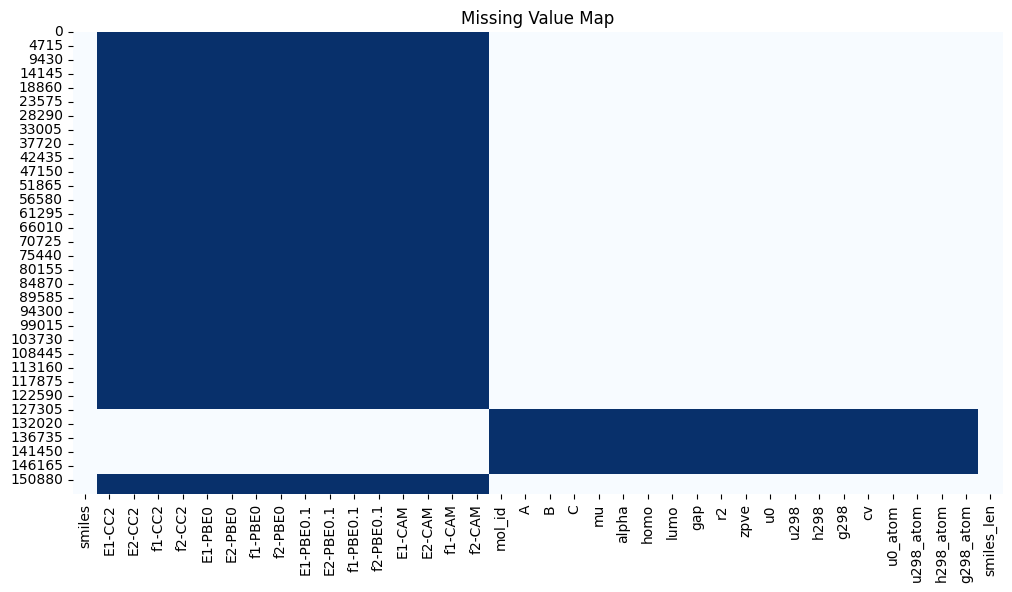

In [123]:
plt.figure(figsize=(12,6))
sns.heatmap(merge_df.isna(),cmap="Blues", cbar=False)
plt.title("Missing Value Map")
plt.show()

In [124]:
missing_pct = (merge_df.isna().mean()*100).sort_values(ascending=False)
missing_pct


E1-CC2        86.008601
E2-CC2        86.008601
f2-CC2        86.008601
f1-CC2        86.008601
E1-PBE0       86.008601
E2-PBE0       86.008601
E2-CAM        86.008601
f1-PBE0       86.008601
f2-PBE0       86.008601
E1-PBE0.1     86.008601
E2-PBE0.1     86.008601
f1-PBE0.1     86.008601
f2-PBE0.1     86.008601
E1-CAM        86.008601
f2-CAM        86.008601
f1-CAM        86.008601
alpha         13.990756
mol_id        13.990756
A             13.990756
B             13.990756
C             13.990756
mu            13.990756
h298          13.990756
homo          13.990756
lumo          13.990756
gap           13.990756
r2            13.990756
zpve          13.990756
u0            13.990756
u298          13.990756
u298_atom     13.990756
g298          13.990756
cv            13.990756
u0_atom       13.990756
g298_atom     13.990756
h298_atom     13.990756
smiles         0.000000
smiles_len     0.000000
dtype: float64

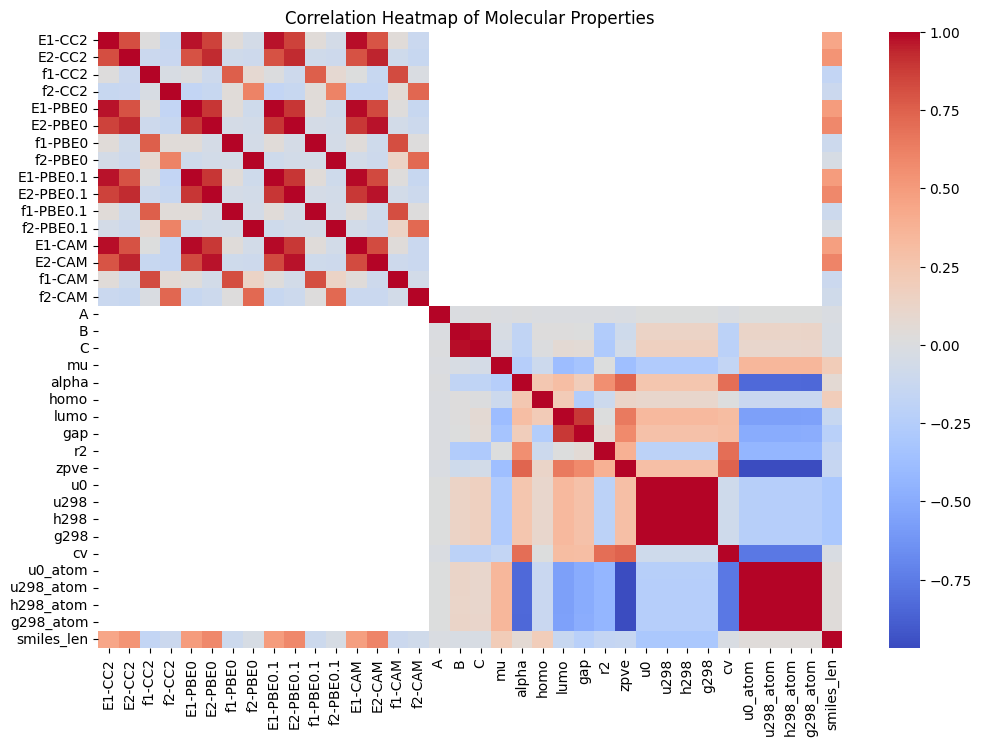

In [129]:
plt.figure(figsize=(12,8))
numeric_df = merge_df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(),cmap="coolwarm",annot=False)
plt.title("Correlation Heatmap of Molecular Properties")
plt.show()

In [132]:
merge_df["num_atoms"] = merge_df["smiles"].apply(lambda x: Chem.MolFromSmiles(x).GetNumAtoms())
merge_df["num_atoms"]

0         1
1         2
2         4
3         6
4         8
         ..
155562    8
155563    8
155564    8
155565    8
155566    5
Name: num_atoms, Length: 155567, dtype: int64

In [134]:
merge_df["num_bonds"] = merge_df["smiles"].apply(lambda x: Chem.MolFromSmiles(x).GetNumBonds())
merge_df["num_bonds"]

0         0
1         1
2         3
3         5
4         7
         ..
155562    9
155563    9
155564    9
155565    9
155566    5
Name: num_bonds, Length: 155567, dtype: int64

In [135]:
merge_df["smiles_len"] = merge_df["smiles"].apply(len)
merge_df["smiles_len"]

0          1
1          3
2          6
3          9
4         12
          ..
155562    12
155563    12
155564    12
155565    12
155566     7
Name: smiles_len, Length: 155567, dtype: int64

In [ ]:
#Different strings can represent same molecule so converting

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol)

merge_df["smiles"] = merge_df["smiles"].apply(canonical)


In [137]:
merge_df = merge_df.drop_duplicates(subset="smiles")


In [138]:
merge_df.columns = merge_df.columns.str.strip() 

In [146]:
x = merge_df["smiles"]
y = merge_df.drop(columns=["smiles"])